In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
fn = '230321_plan_and_results.xlsx'

# OD600

In [4]:
od = pd.read_excel(fn, sheet_name='OD600', header=2, nrows=44)
od_hours = pd.read_excel(fn, sheet_name='OD600', header=0, nrows=1)

In [5]:
od.tail(10)

,#,Sample ID,Medium no.,Replicate,Medium,Species,OD600 - 1,OD600 - 2,OD600 - 3,OD600 - 4,OD600 - 5,OD600 - 6,OD600 - 7,OD600 - 8,OD600 - 9,OD600 - 10,OD600 - 11,OD600 - 12,OD600 - 13,Comment
23,24,8C,8,C,MM- + AA,Ms,0.006,0.092,0.303,0.337,0.362,0.378,0.426,0.471,0.495,0.520,0.567,0.573,0.508,NaN
24,25,9A,9,A,MM- + AA + Thiamine,Ms,0.005,0.093,0.320,0.376,0.413,0.457,0.523,0.635,0.696,0.743,0.810,0.901,1.063,NaN
25,26,9B,9,B,MM- + AA + Thiamine,Ms,0.006,0.095,0.315,0.372,0.411,0.457,0.533,0.690,0.696,0.813,1.241,1.503,1.900,Outlier?
26,27,9C,9,C,MM- + AA + Thiamine,Ms,0.009,0.095,0.314,0.365,0.402,0.448,0.522,0.628,0.682,0.750,0.868,0.912,1.069,NaN
27,28,10A,10,A,MM- + AA + Biotin,Ms,0.005,0.102,0.406,0.492,0.525,0.608,0.675,0.819,0.863,0.923,0.988,1.014,0.419,NaN
28,29,10B,10,B,MM- + AA + Biotin,Ms,0.011,0.095,0.420,0.486,0.530,0.592,0.685,0.816,0.893,0.932,1.010,1.030,0.429,NaN
29,30,10C,10,C,MM- + AA + Biotin,Ms,0.010,0.095,0.424,0.495,0.549,0.608,0.698,0.849,0.885,0.946,1.021,1.046,0.407,NaN
30,31,11A,11,A,MM- + AA + Biotin + Thiamine,Ms,0.007,0.096,0.812,1.067,1.178,1.316,1.516,1.670,1.628,1.627,1.556,1.626,1.578,NaN
31,32,11B,11,B,MM- + AA + Biotin + Thiamine,Ms,0.010,0.098,0.860,1.125,1.252,1.370,1.546,1.670,1.627,1.610,1.562,1.563,1.598,NaN
32,33,11C,11,C,MM- + AA + Biotin + Thiamine,Ms,0.012,0.093,0.860,1.104,1.218,1.369,1.526,1.606,1.638,1.569,1.683,1.602,1.540,NaN


In [6]:
od.columns

Index(['#', 'Sample ID', 'Medium no. ', 'Replicate', 'Medium', 'Species',
       'OD600 - 1', 'OD600 - 2', 'OD600 - 3', 'OD600 - 4', 'OD600 - 5',
       'OD600 - 6', 'OD600 - 7', 'OD600 - 8', 'OD600 - 9', 'OD600 - 10',
       'OD600 - 11', 'OD600 - 12', 'OD600 - 13', 'Comment'],
      dtype='object')

# Remove outliers
Sample 9B is very different from the two others

In [7]:
# od = od.loc[od.Comment.str.contains('Outlier').isna(), :]

In [9]:
od_cols = [x for x in od.columns if 'OD600' in x]
od_idx = [i for i, x in enumerate(od.columns) if 'OD600' in x]
# ['OD600 - day 0',
#        'OD600 - day 1 morning', 'OD600 - day 1 noon',
#        'OD600 - day 1 afternoon', 'OD600 - day 2 morning',
#        'OD600 - day 2 evening', 'OD600 - day 3 afternoon', 'OD600 - day 4', 'OD600 - day 5']

In [10]:
od_long = pd.melt(od, id_vars= ['Sample ID', 'Medium no. ', 'Medium', 'Species'], value_vars=od_cols, var_name = 'Time', value_name= 'OD600')

In [11]:
hours = od_hours.values[0][od_idx]
hours_dict = {key: value for (key, value) in zip(od_cols, hours)}

In [62]:
hours_dict

{'OD600 - 1': 0,
 'OD600 - 2': 6,
 'OD600 - 3': 16,
 'OD600 - 4': 19.5,
 'OD600 - 5': 22,
 'OD600 - 6': 25,
 'OD600 - 7': 30,
 'OD600 - 8': 40,
 'OD600 - 9': 44,
 'OD600 - 10': 51,
 'OD600 - 11': 66,
 'OD600 - 12': 72,
 'OD600 - 13': 188}

In [12]:
od_long['Hours'] = od_long.Time.map(hours_dict)

In [17]:
od_long['Timepoint'] = od_long['Time'].str.split(' - ').str[-1]

In [20]:
od_long.replace({'Species':{'Ms':'Ml'}}, inplace=True)

In [29]:
od_long.columns = [x.rstrip(' ') for x in od_long.columns]


In [30]:
od_long.loc[:, ['Sample ID', 'Medium no.', 'Medium', 'Species', 'Timepoint', 'Hours', 'OD600']].to_csv('auxotrophy_vitamin_screen_batch_1.csv')

# Drop negative controls

In [64]:
# od_no_ctr = od_long.loc[~od_long.Medium.str.contains('negative'), :]
od_no_ctr = od_long.loc[~od_long.Medium.str.contains('BLANK'), :]

In [65]:
od_no_ctr

,Sample ID,Medium no.,Medium,Species,Time,OD600,Hours
0,1A,1,No AA,Ms,OD600 - 1,0.011,0.0
1,1B,1,No AA,Ms,OD600 - 1,0.014,0.0
2,1C,1,No AA,Ms,OD600 - 1,0.010,0.0
3,2A,2,Cysteine,Ms,OD600 - 1,0.003,0.0
4,2B,2,Cysteine,Ms,OD600 - 1,0.006,0.0
...,...,...,...,...,...,...,...
411,10B,10,MM- + AA + Biotin,Ms,OD600 - 13,0.429,188.0
412,10C,10,MM- + AA + Biotin,Ms,OD600 - 13,0.407,188.0
413,11A,11,MM- + AA + Biotin + Thiamine,Ms,OD600 - 13,1.578,188.0
414,11B,11,MM- + AA + Biotin + Thiamine,Ms,OD600 - 13,1.598,188.0


# Plot amino acid auxotrophies for MS

In [66]:
row_idx = (od_long.Species == 'Ms') & ~(od_long.Medium.str.contains('MM-'))
df_Ms_aa = od_long.loc[row_idx, :]

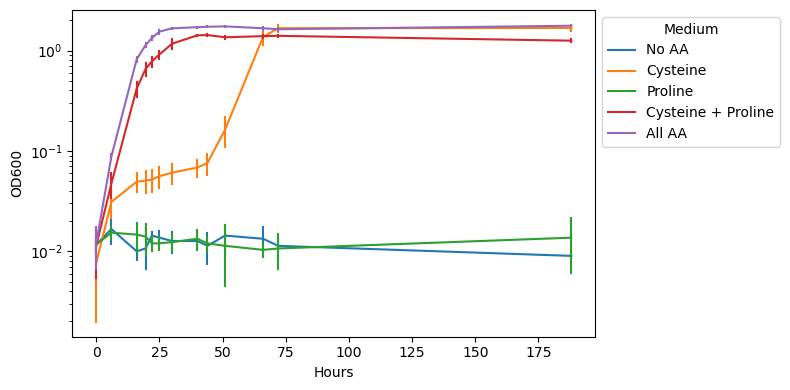

In [67]:
fig, ax = plt.subplots(1, figsize = (8, 4))
ax = sns.lineplot(data = df_Ms_aa, x = 'Hours', y = 'OD600', hue = 'Medium', ci = 'sd', err_style='bars', ax = ax)
#ax = sns.lineplot(data = od_no_ctr, x = 'Hours', y = 'OD600', hue = 'Medium', estimator=None, lw=1)

plt.yscale('log')
# sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=2)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)
plt.tight_layout()
plt.savefig('Ms_AA_OD_with_sd.svg')
plt.savefig('Ms_AA_OD_with_sd.png')

# Plot OD for Ms and vitamin auxotrophies

In [71]:
row_idx = (od_long.Species == 'Ms') & (od_long.Medium.str.contains('MM-'))
# Get the All amino acid and vitamin mix as well
all_amino_acids_idx = od_long["Medium no. "]==5
row_idx[all_amino_acids_idx] = True
df_Ms_vit = od_long.loc[row_idx, :]
df_Ms_vit.loc[all_amino_acids_idx, 'Medium'] = 'MM- + AA + Thiamine + Biotin + Vit. B3'

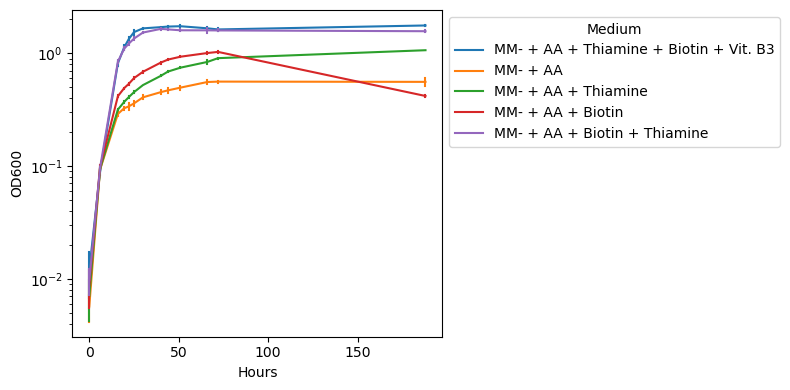

In [72]:
fig, ax = plt.subplots(1, figsize = (8, 4))
ax = sns.lineplot(data = df_Ms_vit, x = 'Hours', y = 'OD600', hue = 'Medium', ci = 'sd', err_style='bars', ax = ax)
#ax = sns.lineplot(data = od_no_ctr, x = 'Hours', y = 'OD600', hue = 'Medium', estimator=None, lw=1)

plt.yscale('log')
# sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=2)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)
plt.tight_layout()
plt.savefig('Ms_vit_OD_with_sd.svg')
plt.savefig('Ms_vit_OD_with_sd.png')

In [73]:
row_idx = (od_long.Species == 'Oa') 
# row_idx[all_amino_acids_idx] = True
df_Oa_vit = od_long.loc[row_idx, :]


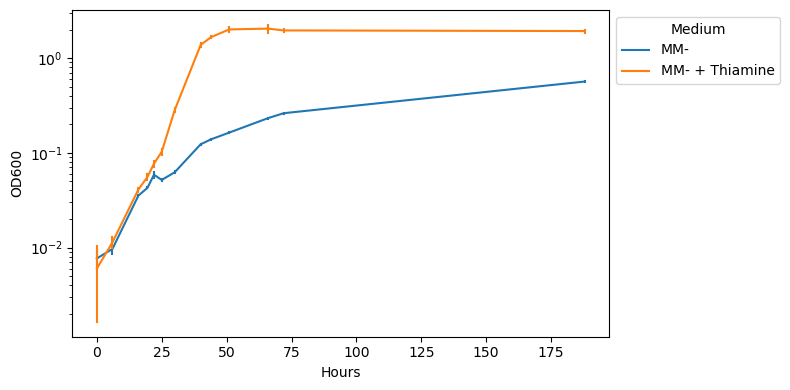

In [74]:
fig, ax = plt.subplots(1, figsize = (8, 4))
ax = sns.lineplot(data = df_Oa_vit, x = 'Hours', y = 'OD600', hue = 'Medium', ci = 'sd', err_style='bars', ax = ax)
#ax = sns.lineplot(data = od_no_ctr, x = 'Hours', y = 'OD600', hue = 'Medium', estimator=None, lw=1)

plt.yscale('log')
# sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=2)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)
plt.tight_layout()
plt.savefig('Oa_vit_OD_with_sd.svg')
plt.savefig('Oa_vit_OD_with_sd.png')

# CFUs

In [86]:
cfu = pd.read_excel(fn, sheet_name='CFU', skiprows = 2, header=1, nrows=33)


In [87]:
cfu.tail()

,#,Sample ID,Medium no.,Replicate,Medium,Species,CFU - 0,CFU - 1
28,29,10B,10,B,MM- + Biotin,Ms,21250000,1.800000e+09
29,30,10C,10,C,MM- + Biotin,Ms,21250000,2.000000e+09
30,31,11A,11,A,MM- + Biotin + Thiamine,Ms,21250000,3.200000e+09
31,32,11B,11,B,MM- + Biotin + Thiamine,Ms,21250000,2.800000e+09
32,33,11C,11,C,MM- + Biotin + Thiamine,Ms,21250000,2.200000e+09


In [88]:
days_dict = {'CFU - 0':0,
             'CFU - 1':3}
cfu_cols = [x for x in cfu.columns if 'CFU' in x]

In [ ]:
#cfu_only_measured = cfu.loc[cfu['CFU - day 3'].notna(), :]

In [103]:
cfu_long = pd.melt(cfu, id_vars= ['Sample ID', 'Medium no. ', 'Medium', 'Species'], value_vars=cfu_cols, var_name = 'Time', value_name= 'CFUs/ml')

In [104]:
cfu_long['Days'] = cfu_long.Time.map(days_dict)

In [105]:
cfu_long

,Sample ID,Medium no.,Medium,Species,Time,CFUs/ml,Days
0,1A,1,No AA,Ms,CFU - 0,2.125000e+07,0
1,1B,1,No AA,Ms,CFU - 0,2.125000e+07,0
2,1C,1,No AA,Ms,CFU - 0,2.125000e+07,0
3,2A,2,Cysteine,Ms,CFU - 0,2.125000e+07,0
4,2B,2,Cysteine,Ms,CFU - 0,2.125000e+07,0
...,...,...,...,...,...,...,...
61,10B,10,MM- + Biotin,Ms,CFU - 1,1.800000e+09,3
62,10C,10,MM- + Biotin,Ms,CFU - 1,2.000000e+09,3
63,11A,11,MM- + Biotin + Thiamine,Ms,CFU - 1,3.200000e+09,3
64,11B,11,MM- + Biotin + Thiamine,Ms,CFU - 1,2.800000e+09,3


In [92]:
# cfu_no_ctr = cfu_long.loc[~cfu_long.Medium.str.contains('Blank'), :]


# Ms Amino acids

In [107]:
row_idx = (cfu_long.Species == 'Ms') & ~(cfu_long.Medium.str.contains('MM-'))
cfu_Ms_AA = cfu_long.loc[row_idx,:]

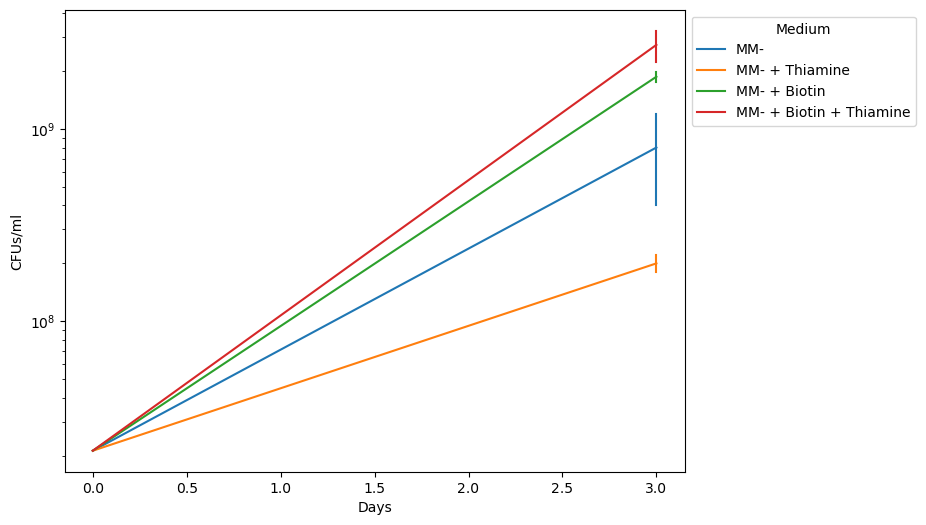

In [116]:
# Plot glucose and glutamic acid side by side
fig, ax = plt.subplots(1, figsize = (8,6))
sns.lineplot(data = cfu_Ms_AA, x = 'Days', y = 'CFUs/ml', hue = 'Medium',  ci = 'sd', err_style='bars', ax = ax)
# sns.move_legend(ax2, "lower center", bbox_to_anchor=(.5, 1), ncol=1)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)

ax.axes.set_yscale('log')
plt.savefig('CFU_Ms_AA.svg')
plt.savefig('CFU_Ms_AA.png')


# Ms Vitamins


In [113]:
row_idx = (cfu_long.Species == 'Ms') & (cfu_long.Medium.str.contains('MM-'))
cfu_Ms_vit = cfu_long.loc[row_idx,:]

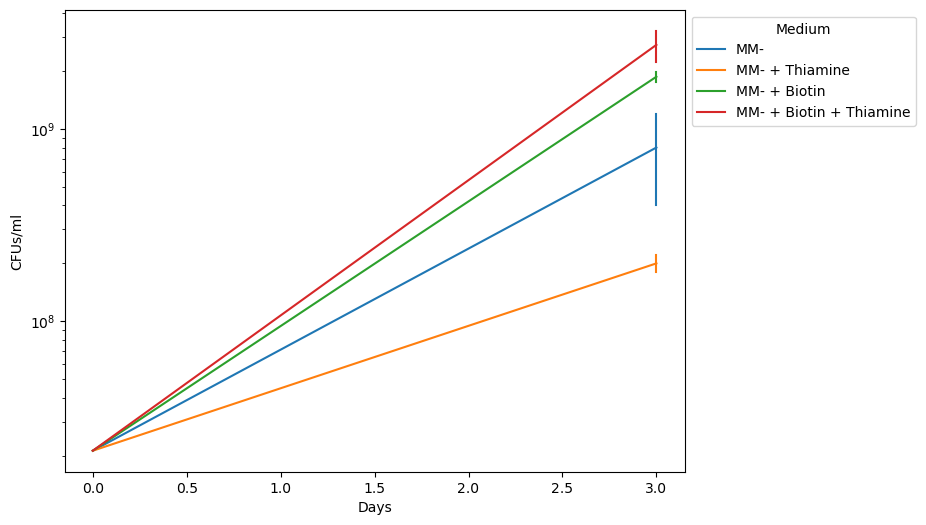

In [119]:
fig, ax = plt.subplots(1, figsize = (8,6))
sns.lineplot(data = cfu_Ms_vit, x = 'Days', y = 'CFUs/ml', hue = 'Medium',
             ci = 'sd', err_style='bars', ax = ax)
# sns.move_legend(ax2, "lower center", bbox_to_anchor=(.5, 1), ncol=1)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)

ax.axes.set_yscale('log')
plt.savefig('CFU_Ms_vit.png')
plt.savefig('CFU_Ms_vit.svg')


# Oa


In [115]:
row_idx = (cfu_long.Species == 'Oa')
cfu_Oa = cfu_long.loc[row_idx,:]

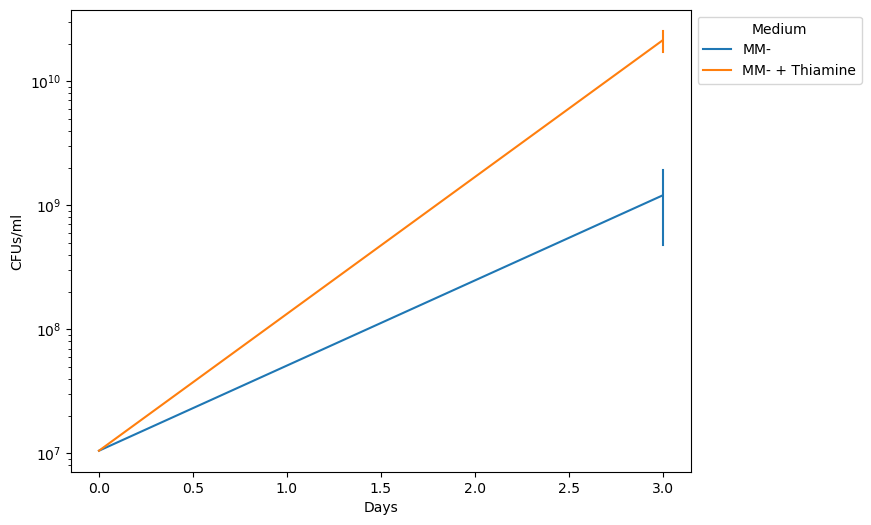

In [120]:
fig, ax = plt.subplots(1, figsize = (8,6))
sns.lineplot(data = cfu_Oa, x = 'Days', y = 'CFUs/ml', hue = 'Medium',
             ci = 'sd', err_style='bars', ax = ax)
# sns.move_legend(ax2, "lower center", bbox_to_anchor=(.5, 1), ncol=1)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)

ax.axes.set_yscale('log')
plt.savefig('CFU_Oa_vit.png')
plt.savefig('CFU_Oa_vit.svg')
